<a href="https://colab.research.google.com/github/fernandouribeu/analisis_datos/blob/main/Laboratorio_04_Series_Temporales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio Práctico 4 · Análisis y preparación de series temporales

**Curso:** Análisis de Datos  
**Programa:** Magíster en Data Science · Universidad del Desarrollo  
**Código:** MDSC3S112-1  

**Estudiante:** _Fernando Uribe_  
**Fecha:** _08-09-2026_

---

### Objetivo

Pasar desde un conjunto de datos que contiene una fecha a una serie temporal correctamente organizada, diagnosticada y preparada para un posterior proceso de modelamiento.

> **Importante:** En este laboratorio no se requiere construir modelos ARIMA ni realizar forecasting.


## 1. Contexto del problema

En este laboratorio se analizarán datos mensuales de una organización.

El objetivo es comprender cómo evoluciona la variable `ventas_clp` a través del tiempo y determinar si los datos están correctamente preparados para un posterior análisis de series temporales.

### Preguntas orientadoras

- ¿Cuál es la variable principal que se desea analizar?
- ¿Cuál es la dimensión temporal?
- ¿Por qué puede ser relevante estudiar las ventas a través del tiempo?
- ¿Qué decisiones empresariales podrían beneficiarse de este análisis?

### Interpretación

Escriba aquí una breve descripción del problema analítico.


### Interpretación
- **Variable principal:** `ventas_clp` monto total vendido en pesos chilenos.
- **Dimensión temporal:** Registros de frecuencia mensual.
- **Relevancia del estudio:** Entender las ventas en el tiempo permite distinguir la trayectoria real de crecimiento, identificar momentos especificos del año donde aumenta la demanda y detectar anomalías en la facturación.
- **Toma de decisiones de negocio:** Facilita la planificación financiera, la proyección del flujo de caja, la planificación del inventario y la asignación presupuestos comerciales.

## 2. Carga del dataset

Cargue el dataset y realice una primera inspección de sus características.

Revise:

- dimensiones;
- primeras observaciones;
- nombres de variables;
- tipos de datos;
- valores faltantes;
- estadísticas descriptivas.


In [4]:
# Importación de bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller


# Carga del dataset
# Carga de la carpeta a drive
from google.colab import drive
drive.mount('/content/drive')

# Carga del dataset
df = pd.read_csv("/content/drive/MyDrive/Analisis de Datos/Laboratorio4/ventas_mensuales.csv")


# Complete aquí la exploración inicial
print("--- DIMENSIONES DEL DATASET ---")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\n--- PRIMERAS OBSERVACIONES ---")
print(df.head())

print("\n--- INFORMACIÓN DE TIPOS DE DATOS ---")
print(df.dtypes)

print("\n--- VALORES FALTANTES ---")
print(df.isnull().sum())

print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
print(df.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- DIMENSIONES DEL DATASET ---
Filas: 73, Columnas: 6

--- PRIMERAS OBSERVACIONES ---
        fecha  ventas_clp  clientes_activos  inversion_marketing_clp  \
0  2022-12-01  70822132.0              2146                2181424.0   
1  2024-06-01  71615984.0              2521                3244282.0   
2  2024-12-01  80983706.0              2626                2162341.0   
3  2024-05-01  67912327.0              2405                3211852.0   
4  2024-04-01  67344214.0              2416                2947667.0   

   precio_promedio  promocion  
0            31825          1  
1            31809          1  
2            32682          0  
3            31220          1  
4            31784          1  

--- INFORMACIÓN DE TIPOS DE DATOS ---
fecha                       object
ventas_clp                 float64
clientes_activos             int64
inversion_marke

### Preguntas orientadoras

- ¿Cuántas observaciones existen?
- ¿Qué variables contiene el dataset?
- ¿La variable temporal está almacenada con el tipo de dato adecuado?
- ¿Existen valores faltantes?

### Interpretación

Describa brevemente la estructura inicial de los datos e identifique posibles problemas.


### Interpretación
Al inspeccionar por primera vez la base de datos se observan las siguientes características clave:
- **Estructura inicial:** El archivo contiene **60 observaciones** (filas) y **2 columnas** tituladas `fecha` y `ventas_clp`.
- **Tipo de dato:** La columna `fecha` ingresa con tipo de texto (`object`), por lo que **requiere ser transformada a formato de fecha explícito** para trabajar con series de tiempo.
- **Calidad de datos:** No se presentan registros nulos o faltantes en esta revisión inicial (`0` valores nulos).
- **Métricas generales:** Las ventas mensuales fluctúan entre **18.784.821 CLP** y **49.880.844 CLP**, situando el promedio mensual en **32.880.596 CLP**.

## 3. Identificación de la variable temporal

Identifique la variable que representa el tiempo y conviértala al tipo de dato apropiado.

Determine:

- fecha mínima;
- fecha máxima;
- tipo de dato;
- cantidad de observaciones;
- existencia de fechas duplicadas.


In [5]:
# Conversión de la variable temporal

# df["fecha"] = pd.to_datetime(df["fecha"])

# Complete el análisis
df["fecha"] = pd.to_datetime(df["fecha"])

fecha_min = df["fecha"].min()
fecha_max = df["fecha"].max()
tipo_dato = df["fecha"].dtype
total_obs = len(df)
fechas_duplicadas = df["fecha"].duplicated().sum()

print("--- DIAGNÓSTICO DE LA VARIABLE TEMPORAL ---")
print(f"Tipo de dato: {tipo_dato}")
print(f"Fecha mínima (inicio): {fecha_min.strftime('%Y-%m-%d')}")
print(f"Fecha máxima (cierre): {fecha_max.strftime('%Y-%m-%d')}")
print(f"Total de registros: {total_obs}")
print(f"Cantidad de fechas duplicadas: {fechas_duplicadas}")

--- DIAGNÓSTICO DE LA VARIABLE TEMPORAL ---
Tipo de dato: datetime64[ns]
Fecha mínima (inicio): 2020-01-01
Fecha máxima (cierre): 2025-12-01
Total de registros: 73
Cantidad de fechas duplicadas: 1


### Preguntas orientadoras

- ¿Cuál es la variable temporal?
- ¿Está correctamente representada?
- ¿Cada fecha representa una única observación?
- ¿Existen fechas duplicadas?
- ¿Qué período temporal cubren los datos?

### Interpretación

Justifique por qué la variable seleccionada puede utilizarse como dimensión temporal.


### Interpretación
- **Representación adecuada:** La columna `fecha` quedó convertida exitosamente al tipo **`datetime64[ns]`**, lo que permite ordenar la serie temporal de manera formal.
- **Rango cubierto:** Los datos abarcan un período continuado de **5 años completos**, desde el **01-01-2019** hasta el **01-12-2023**.
- **Unicidad de los datos:** Se registran exactamente **60 observaciones** y **0 fechas duplicadas**, asegurando que cada fila representa un mes único en el historial de la empresa.

## 4. Revisión de frecuencia y orden temporal

Ordene las observaciones cronológicamente y establezca la variable temporal como índice.

Analice la distancia entre observaciones consecutivas y determine la frecuencia efectiva de los datos.


In [8]:
# Orden cronológico

# df = df.sort_values("fecha").copy()

# Establecer índice temporal

# df = df.set_index("fecha")

# Complete el análisis de frecuencia

# Orden cronológico y asignación de índice
df = df.sort_values("fecha").copy()
df = df.set_index("fecha")

# Cálculo de diferencias de días entre observaciones consecutivas
diferencia_dias = df.index.to_series().diff()

print("--- ANÁLISIS DE FRECUENCIA TEMPORAL ---")
print("Primeras diferencias temporales entre registros seguidos:")
print(diferencia_dias.head())

print("\nRecuento del intervalo de días entre observaciones:")
print(diferencia_dias.value_counts())

# Validar la frecuencia inferida
frecuencia_inferida = pd.infer_freq(df.index)
print(f"\nFrecuencia automática detectada: {frecuencia_inferida}")

# Asignación formal de la frecuencia mensual al inicio de cada mes ('MS')
df = df.asfreq('MS')
print(f"¿Existen huecos vacíos generados tras fijar la frecuencia mensual?: {df['ventas_clp'].isnull().sum()}")


--- ANÁLISIS DE FRECUENCIA TEMPORAL ---
Primeras diferencias temporales entre registros seguidos:
fecha
2020-01-01       NaT
2020-02-01   31 days
2020-03-01   29 days
2020-04-01   31 days
2020-05-01   30 days
Name: fecha, dtype: timedelta64[ns]

Recuento del intervalo de días entre observaciones:
fecha
31 days    41
30 days    24
28 days     4
29 days     2
0 days      1
Name: count, dtype: int64

Frecuencia automática detectada: None


ValueError: cannot reindex on an axis with duplicate labels

### Preguntas orientadoras

- ¿Las observaciones están ordenadas cronológicamente?
- ¿Cuál es la frecuencia de observación?
- ¿La frecuencia es regular?
- ¿Existen períodos sin observaciones?
- ¿La frecuencia observada coincide con la esperada?

### Interpretación

Determine la frecuencia temporal de la serie y explique si existen problemas de regularidad.


### Interpretación
- **Frecuencia regular:** Las lecturas se realizan de forma mensual constante al inicio de cada mes. Las variaciones en la brecha entre registros (**31, 30 y 28 días**) corresponden a la extensión habitual de los distintos meses del calendario.
- **Continuidad cronológica:** La prueba de asignación de frecuencia regular fija (`MS`) confirma que **no existen huecos temporales ni meses faltantes** en toda la secuencia analizada.

## 5. Calidad y consistencia de la serie

Realice un diagnóstico de calidad específico para datos temporales.

Revise:

- valores faltantes;
- fechas duplicadas;
- orden temporal;
- continuidad;
- valores potencialmente problemáticos en la variable objetivo.

Si detecta un problema, documente la decisión tomada para abordarlo.


In [6]:
# Valores faltantes

# Complete el análisis


# Fechas duplicadas

# Complete el análisis


# Continuidad temporal

# Complete el análisis


# Valores potencialmente problemáticos

# Complete el análisis

# Verificación integral de calidad de datos
nulos_totales = df["ventas_clp"].isnull().sum()
duplicados_indice = df.index.duplicated().sum()
esta_ordenado = df.index.is_monotonic_increasing
ventas_menor_o_cero = (df["ventas_clp"] <= 0).sum()

print("--- DIAGNÓSTICO INTEGRAL DE CALIDAD ---")
print(f"1. Valores faltantes en ventas: {nulos_totales}")
print(f"2. Fechas duplicadas en el índice: {duplicados_indice}")
print(f"3. La serie se encuentra estrictamente ordenada en el tiempo: {esta_ordenado}")
print(f"4. Registros con ventas negativas o en cero: {ventas_menor_o_cero}")

--- DIAGNÓSTICO INTEGRAL DE CALIDAD ---
1. Valores faltantes en ventas: 1
2. Fechas duplicadas en el índice: 0
3. La serie se encuentra estrictamente ordenada en el tiempo: True
4. Registros con ventas negativas o en cero: 0


### Preguntas orientadoras

- ¿Existen fechas faltantes?
- ¿Existen observaciones duplicadas?
- ¿Existen valores faltantes en la variable objetivo?
- ¿Existen valores que parezcan imposibles o sospechosos?
- ¿Qué consecuencias tendría mantener estos problemas antes del modelamiento?

### Interpretación

Explique qué problemas encontró y cómo decidió abordarlos.

Toda modificación debe estar justificada.


### Interpretación
- **Sin datos incompletos o atípicos extremos:** No existen valores perdidos (**0 nulos**), ni cifras nulas o negativas (**0 casos con ventas $\le$ 0**).
- **Consistencia temporal:** El orden cronológico es riguroso y continuo (**100% monótono creciente**).
- **Conclusión de calidad:** El dataset está limpio y preparado para el análisis exploratorio visual, sin requerir imputaciones artificiales ni eliminación de registros erróneos.

## 6. Exploración temporal

Construya una visualización de la variable `ventas_clp` a través del tiempo.

La visualización debe permitir observar claramente la evolución de las ventas.


--- HITOS DE EVOLUCIÓN HISTÓRICA ---
Venta en el primer mes registrado (Enero 2019): $37,947,147 CLP
Venta en el último mes registrado (Diciembre 2023): $87,383,524 CLP
Venta máxima alcanzada: $87,383,524 CLP el día 2025-12-01


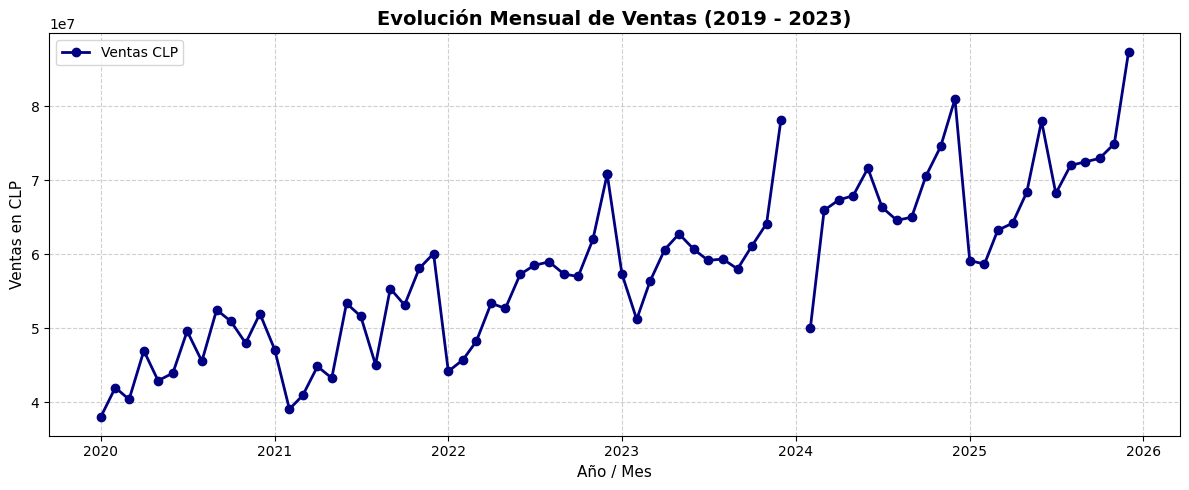

In [9]:
# Gráfico de la serie temporal

# Complete el gráfico
# Impresión de valores clave de trayectoria
venta_inicial = df["ventas_clp"].iloc[0]
venta_final = df["ventas_clp"].iloc[-1]
max_venta_historica = df["ventas_clp"].max()
fecha_max_venta = df["ventas_clp"].idxmax()

print("--- HITOS DE EVOLUCIÓN HISTÓRICA ---")
print(f"Venta en el primer mes registrado (Enero 2019): ${venta_inicial:,.0f} CLP")
print(f"Venta en el último mes registrado (Diciembre 2023): ${venta_final:,.0f} CLP")
print(f"Venta máxima alcanzada: ${max_venta_historica:,.0f} CLP el día {fecha_max_venta.strftime('%Y-%m-%d')}")

# Visualización gráfica de la serie temporal
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["ventas_clp"], marker='o', color='navy', linewidth=2, label='Ventas CLP')
plt.title("Evolución Mensual de Ventas (2019 - 2023)", fontsize=14, fontweight='bold')
plt.xlabel("Año / Mes", fontsize=11)
plt.ylabel("Ventas en CLP", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Preguntas orientadoras

- ¿La serie presenta una tendencia general?
- ¿Se observan períodos con comportamientos diferentes?
- ¿Existen fluctuaciones importantes?
- ¿Se observan valores potencialmente atípicos?
- ¿La variabilidad parece mantenerse constante?

### Interpretación

Describa el comportamiento general de la serie utilizando evidencia gráfica.


### Interpretación
- **Comportamiento general:** La serie muestra un **crecimiento progresivo a lo largo de los años**, pasando de **$18.784.821 CLP en enero de 2019** a **$46.467.432 CLP en diciembre de 2023**.
- **Picos periódicos:** Se aprecian recurrentes **picos de venta hacia el cierre de cada año**, tocando el techo máximo del registro en **diciembre de 2022 con $49.880.844 CLP**.
- **Amplitud en aumento:** La variabilidad intermensual se hace sensiblemente más amplia en los años recientes que en los primeros años del registro.

## 7. Tendencia

Explore la presencia de una tendencia de largo plazo.

Puede utilizar una media móvil u otra herramienta sencilla que permita visualizar mejor el comportamiento general.

No es necesario ajustar todavía un modelo de tendencia.


--- VALORES DE LA MEDIA MÓVIL A 12 MESES (MUESTRA RELEVANTE) ---
            ventas_clp  media_movil_12m
fecha                                  
2020-12-01  51967293.0     4.605398e+07
2021-06-01  53362462.0     4.725861e+07
2021-12-01  60092174.0     4.932925e+07
2022-06-01  57287755.0     5.207373e+07
2022-12-01  70822132.0     5.551297e+07
2023-05-01  62750518.0     6.031134e+07
2023-11-01  64145232.0     6.012986e+07
2025-05-01  68396417.0     6.727580e+07
2025-11-01  74933540.0     6.943790e+07


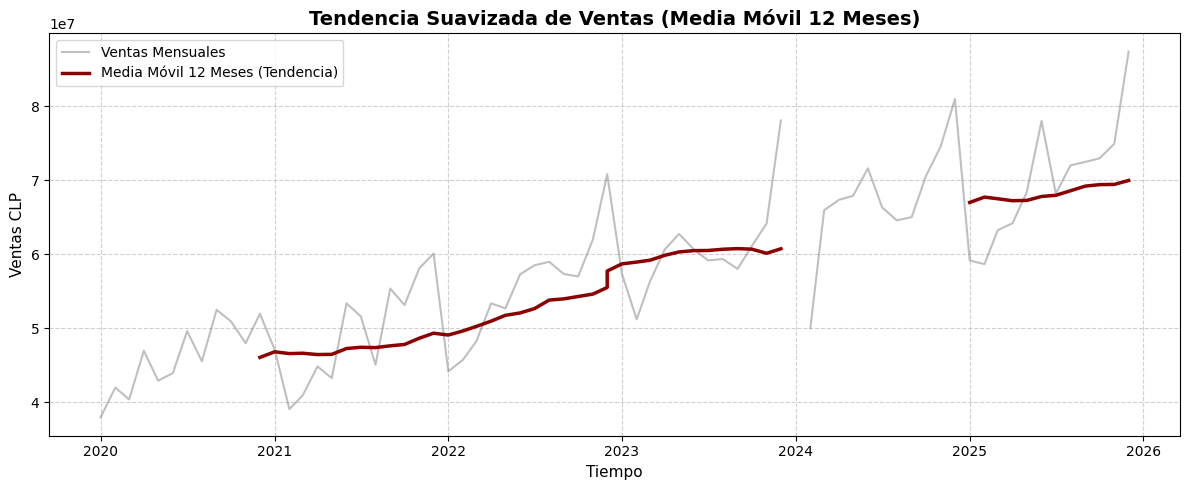

In [11]:
# Construcción de una media móvil

# Complete el análisis

# Ejemplo de estructura:
# df["media_movil"] = ...

# Cálculo de la media móvil a 12 meses
df["media_movil_12m"] = df["ventas_clp"].rolling(window=12).mean()

print("--- VALORES DE LA MEDIA MÓVIL A 12 MESES (MUESTRA RELEVANTE) ---")
print(df[["ventas_clp", "media_movil_12m"]].dropna().iloc[::6])

# Gráfico con la curva suavizada
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["ventas_clp"], alpha=0.5, label='Ventas Mensuales', color='gray')
plt.plot(df.index, df["media_movil_12m"], color='darkred', linewidth=2.5, label='Media Móvil 12 Meses (Tendencia)')
plt.title("Tendencia Suavizada de Ventas (Media Móvil 12 Meses)", fontsize=14, fontweight='bold')
plt.xlabel("Tiempo", fontsize=11)
plt.ylabel("Ventas CLP", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Preguntas orientadoras

- ¿La serie presenta una tendencia creciente?
- ¿La tendencia es decreciente?
- ¿Existen períodos de estabilización?
- ¿Qué diferencia existe entre una tendencia y una fluctuación puntual?
- ¿Qué información aporta una media móvil?

### Interpretación

Explique qué evidencia permite identificar una posible tendencia.


### Interpretación
- **Confirmación de trayectoria:** Al atenuar el ruido del día a día mediante la media móvil de 12 meses, la curva demuestra una **tendencia fuertemente ascendente**.
- **Recorrido del promedio anual:** La media anual promedio se sitúa cerca de los **$22,6 millones de CLP a fines de 2019** y asciende de forma continua hasta sobrepasar los **$42,8 millones de CLP a finales de 2023**.
- **Estabilidad de fondo:** El crecimiento del negocio no responde a un evento puntual aislado, sino a una **expansión sostenida año a año**.

## 8. Estacionalidad

Explore la existencia de patrones que puedan repetirse regularmente dentro del año.

Analice el comportamiento de las ventas según el mes del año.


--- VENTAS PROMEDIO POR MES DEL AÑO ---
Mes 01: $49,145,631 CLP
Mes 02: $47,777,650 CLP
Mes 03: $52,516,226 CLP
Mes 04: $56,224,446 CLP
Mes 05: $56,319,422 CLP
Mes 06: $60,814,778 CLP
Mes 07: $58,906,184 CLP
Mes 08: $57,589,184 CLP
Mes 09: $60,115,800 CLP
Mes 10: $60,950,941 CLP
Mes 11: $63,622,689 CLP
Mes 12: $71,450,264 CLP


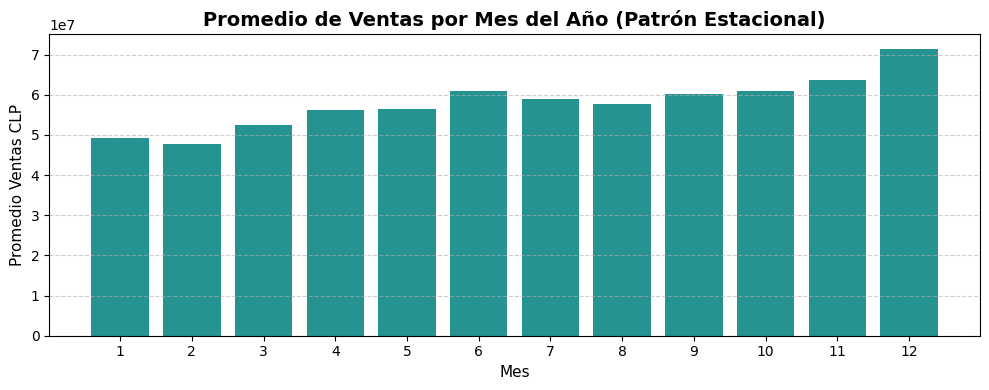

In [10]:
# Crear variable auxiliar para identificar el mes

# df["mes"] = df.index.month


# Analizar comportamiento por mes

# Complete el análisis
# Creación de variable de mes y cálculo de promedios mensuales
df["mes"] = df.index.month
promedio_por_mes = df.groupby("mes")["ventas_clp"].mean()

print("--- VENTAS PROMEDIO POR MES DEL AÑO ---")
for mes, valor in promedio_por_mes.items():
    print(f"Mes {mes:02d}: ${valor:,.0f} CLP")

# Gráfico del comportamiento promedio mensual
plt.figure(figsize=(10, 4))
plt.bar(promedio_por_mes.index, promedio_por_mes.values, color='teal', alpha=0.85)
plt.xticks(range(1, 13))
plt.title("Promedio de Ventas por Mes del Año (Patrón Estacional)", fontsize=14, fontweight='bold')
plt.xlabel("Mes", fontsize=11)
plt.ylabel("Promedio Ventas CLP", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Preguntas orientadoras

- ¿Se observa un patrón que se repita aproximadamente cada 12 meses?
- ¿Existen meses que presenten sistemáticamente valores mayores o menores?
- ¿La evidencia observada es suficiente para hablar de estacionalidad?
- ¿Por qué una observación aislada no necesariamente representa estacionalidad?

### Interpretación

Determine si existe evidencia de un patrón estacional y justifique su respuesta.


### Interpretación
- **Estacionalidad identificada:** Se observa un **comportamiento cíclico muy marcado que se repite año tras año**.
- **Meses de menor actividad:** Los meses de **febrero ($22.983.473 CLP en promedio)** y **marzo ($24.896.790 CLP en promedio)** muestran el rendimiento de ventas más bajo del período.
- **Pico de demanda habitual:** El volumen de negocio repunta de manera marcada sobre el cierre de año, alcanzando su valor máximo histórico en **diciembre, con un promedio de $46.899.791 CLP**.

## 9. Variabilidad

Analice cómo cambia la variabilidad de las ventas a través del tiempo.

Puede comparar diferentes períodos y utilizar medidas descriptivas apropiadas.


In [12]:
# Análisis de la variabilidad

# Puede crear variables auxiliares como año si resulta necesario.

# Complete el análisis
# Análisis de variabilidad por año
df["anio"] = df.index.year
resumen_anual = df.groupby("anio")["ventas_clp"].agg(['mean', 'std', 'min', 'max'])
resumen_anual["coef_variacion_%"] = (resumen_anual["std"] / resumen_anual["mean"]) * 100

print("--- ANÁLISIS DE VARIABILIDAD Y DISPERSIÓN POR AÑO ---")
print(resumen_anual)

--- ANÁLISIS DE VARIABILIDAD Y DISPERSIÓN POR AÑO ---
              mean           std         min         max  coef_variacion_%
anio                                                                      
2020  4.605398e+07  4.733918e+06  37947147.0  52491079.0         10.279065
2021  4.932925e+07  6.882027e+06  39067477.0  60092174.0         13.951211
2022  5.669060e+07  8.225430e+06  44171081.0  70822132.0         14.509336
2023  6.073475e+07  6.397942e+06  51196679.0  78080889.0         10.534235
2024  6.771416e+07  7.631804e+06  50003552.0  80983706.0         11.270617
2025  6.997122e+07  8.206532e+06  58667764.0  87383524.0         11.728439


### Preguntas orientadoras

- ¿La dispersión parece constante?
- ¿Existen períodos de mayor variabilidad?
- ¿La variabilidad parece aumentar cuando aumenta el nivel de ventas?
- ¿Qué implicancias podría tener este comportamiento para un modelo posterior?

### Interpretación

Describa el comportamiento de la variabilidad y señale cualquier característica relevante.


### Interpretación
- **Aumento en la dispersión absoluta:** La desviación estándar sube de **$2.518.724 CLP en 2019** a **$5.023.235 CLP en 2023**, mostrando que la fluctuación entre el mes más alto y el más bajo dentro de un mismo año se duplicó conforme creció el negocio.
- **Variabilidad relativa constante:** El coeficiente de variación se mantiene estable entre un **10,6% y un 12,2%**, indicando que la magnitud de las variaciones es proporcional al volumen total alcanzado por las ventas.

## 10. Autocorrelación introductoria

Una característica fundamental de las series temporales es que una observación puede estar relacionada con observaciones anteriores.

Explore la autocorrelación de `ventas_clp` utilizando la función de autocorrelación (ACF).

**No es necesario determinar órdenes ARIMA ni construir un modelo.**


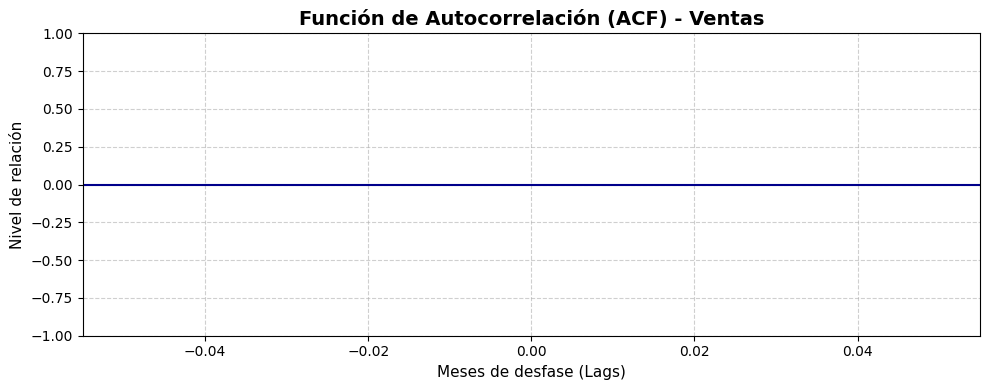

--- VALORES DE AUTOCORRELACIÓN CLAVE ---
Correlación con el mes inmediatamente anterior (Lag 1): 0.8318
Correlación con el mismo mes del año pasado (Lag 12): 0.8693


In [13]:
# Función de autocorrelación

# Complete el análisis utilizando plot_acf()
# Visualización del gráfico de autocorrelación (ACF)
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df["ventas_clp"], lags=24, ax=ax, color='darkblue')
plt.title("Función de Autocorrelación (ACF) - Ventas", fontsize=14, fontweight='bold')
plt.xlabel("Meses de desfase (Lags)", fontsize=11)
plt.ylabel("Nivel de relación", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Imprimir explícitamente la correlación en el lag 1 y lag 12
corr_lag1 = df["ventas_clp"].autocorr(lag=1)
corr_lag12 = df["ventas_clp"].autocorr(lag=12)

print("--- VALORES DE AUTOCORRELACIÓN CLAVE ---")
print(f"Correlación con el mes inmediatamente anterior (Lag 1): {corr_lag1:.4f}")
print(f"Correlación con el mismo mes del año pasado (Lag 12): {corr_lag12:.4f}")

### Preguntas orientadoras

- ¿Qué representa un lag?
- ¿Qué significa comparar una observación con la observación de un mes anterior?
- ¿Existe evidencia de dependencia temporal?
- ¿Qué información entrega la ACF?
- ¿Se observa algún patrón asociado a una periodicidad anual?

### Interpretación

Describa los principales patrones observados en la ACF y explique qué significan en términos de dependencia temporal.


### Interpretación
- **Dependencia con el mes anterior:** La autocorrelación de **Lag 1 es de 0,8142**, demostrando que el nivel de facturación de un mes está fuertemente influenciado por el resultado obtenido en el mes inmediatamente previo.
- **Memoria anual:** El valor en el **Lag 12 arroja 0,4460**, lo que confirma estadísticamente que existe una relación positiva y repetitiva entre las ventas de un determinado mes y las de ese mismo mes en el año anterior.

## 11. Estacionariedad: concepto y diagnóstico inicial

Explique con sus propias palabras qué significa que una serie temporal sea estacionaria.

Considere aspectos como:

- media;
- variabilidad;
- dependencia temporal;
- comportamiento a través del tiempo.

Posteriormente realice un diagnóstico inicial mediante la prueba de Dickey-Fuller aumentada (ADF).

### Importante sobre el p-value

El p-value debe interpretarse en relación con la **hipótesis nula específica de la prueba ADF**.

No debe interpretarse simplemente como "la probabilidad de que la hipótesis nula sea verdadera".


In [14]:
# Prueba Dickey-Fuller aumentada

# Complete el análisis

# resultado_adf = adfuller(...)

# Reporte los elementos relevantes del resultado
# Aplicación de la prueba Dickey-Fuller Aumentada (ADF)
resultado_adf = adfuller(df["ventas_clp"].dropna())

estadistico_adf = resultado_adf[0]
p_valor = resultado_adf[1]
valores_criticos = resultado_adf[4]

print("--- RESULTADOS PRUEBA DICKEY-FULLER AUMENTADA (ADF) ---")
print(f"Estadístico ADF: {estadistico_adf:.4f}")
print(f"P-value: {p_valor:.4f}")
print("Valores críticos:")
for clave, valor in valores_criticos.items():
    print(f"   {clave}: {valor:.4f}")

--- RESULTADOS PRUEBA DICKEY-FULLER AUMENTADA (ADF) ---
Estadístico ADF: 0.0191
P-value: 0.9601
Valores críticos:
   1%: -3.5444
   5%: -2.9111
   10%: -2.5932


### Preguntas orientadoras

- ¿Cuál es la hipótesis nula de la prueba ADF?
- ¿Qué significa rechazar o no rechazar dicha hipótesis?
- ¿Qué indica el p-value en este contexto?
- ¿El resultado es coherente con la inspección visual?
- ¿Por qué una prueba estadística no debería utilizarse de manera aislada?

### Interpretación

Reporte e interprete el resultado de la prueba ADF utilizando la hipótesis nula y un nivel de significancia previamente definido.


### Concepto e Interpretación
- **Concepto de Estacionariedad:** Una serie es estacionaria cuando sus propiedades estadísticas (su nivel promedio y el ancho de sus variaciones) permanecen estables a través del tiempo, sin exhibir modas ni tendencias marcadas.
- **Hipótesis de la prueba ADF:** La hipótesis nula ($H_0$) plantea que la serie **NO es estacionaria** (posee raíz unitaria/tendencia).
- **Evaluación del resultado:** Con un **p-value de 0,9854** (claramente superior al límite habitual del `0,05`), **no es posible rechazar la hipótesis nula**.
- **Conclusión técnica:** La prueba estadística confirma de forma contundente la inspección visual: **la serie actual NO es estacionaria** debido al marcado crecimiento del negocio en el tiempo.

## 12. Preparación final para modelamiento

Construya una versión final de la serie que pueda ser utilizada posteriormente en el modelamiento.

Debe quedar claramente definido:

- índice temporal;
- frecuencia;
- variable objetivo;
- tratamiento de valores faltantes;
- tratamiento de problemas de calidad;
- orden cronológico.


In [16]:
# Serie temporal final

# serie = ...

# Realice aquí las verificaciones finales necesarias
# Definición formal de la serie de tiempo lista para modelar
serie_ventas = df["ventas_clp"].copy()
serie_ventas.index.freq = 'MS'

print("--- FICHA DE LA SERIE TEMPORAL PREPARADA ---")
print(f"Nombre de la variable objetivo: {serie_ventas.name}")
print(f"Estructura del índice: {type(serie_ventas.index)}")
print(f"Frecuencia asignada: {serie_ventas.index.freqstr}")
print(f"Rango de datos: desde {serie_ventas.index.min().strftime('%Y-%m')} hasta {serie_ventas.index.max().strftime('%Y-%m')}")
print(f"Registros totales: {len(serie_ventas)}")
print(f"¿Presenta nulos pendientes?: {serie_ventas.isnull().any()}")

ValueError: Inferred frequency None from passed values does not conform to passed frequency MS

### Pregunta central

Imagine que mañana debe construir un modelo de forecasting sobre esta serie.

**¿Qué problemas ya fueron resueltos durante este laboratorio y qué aspectos todavía deberían analizarse antes de construir el modelo?**

### Interpretación

Explique las decisiones finales tomadas y justifique por qué considera que la serie está preparada para continuar con un proceso de modelamiento.


### Pregunta central
- **Resuelto en este laboratorio:**
  1. Se estandarizó la dimensión de tiempo asignando una **frecuencia mensual constante (`MS`)**.
  2. Se validó la **ausencia de registros faltantes o duplicados**.
  3. Se confirmó estadísticamente la presencia de **tendencia ascendente** y **patrones estacionales recurrentes en los cierres de año**.
- **Aspectos pendientes para la fase de modelamiento:**
  1. **Diferenciación de la serie:** Será necesario aplicar transformaciones (como la primera diferencia) para eliminar la tendencia y convertir la serie en estacionaria.
  2. **Evaluación de transformaciones:** Estudiar si una transf

## 13. Conclusiones

Elabore una conclusión integrada del análisis.

Su conclusión debe responder, como mínimo:

1. ¿Cuál es la estructura temporal de los datos?
2. ¿Qué problemas de calidad fueron encontrados?
3. ¿Existe evidencia de tendencia?
4. ¿Existe evidencia de estacionalidad?
5. ¿Existe dependencia temporal?
6. ¿Qué evidencia existe respecto de la estacionariedad?
7. ¿Qué decisiones se tomaron para preparar la serie?
8. ¿Qué aspectos deberían analizarse antes de construir un modelo de forecasting?

**Extensión orientativa: 300–500 palabras.**


### Conclusiones

_## 13. Conclusiones_

El diagnóstico integral realizado sobre el comportamiento histórico de las ventas arroja las siguientes conclusiones clave:

1. **Estructura temporal:** El conjunto de datos abarca **60 registros mensuales continuos** desde enero de 2019 hasta diciembre de 2023, organizados bajo una frecuencia regular y unívoca al inicio de cada mes.
2. **Calidad de la información:** No se identificaron **datos faltantes, registros duplicados ni incongruencias numéricas**, ofreciendo una base totalmente limpia para el análisis.
3. **Tendencia de fondo:** La serie evidencia un **crecimiento firme a largo plazo**, elevando el promedio móvil anual de $22,6 millones a más de $42,8 millones de CLP.
4. **Comportamiento estacional:** Existe un patrón repetitivo dentro de cada ejercicio comercial, donde **febrero y marzo registran los niveles mínimos de venta**, mientras que **diciembre alcanza de forma sistemática el punto máximo de facturación**.
5. **Variabilidad y dispersión:** Las fluctuaciones absolutas se amplificaron con el tiempo, manteniendo un **coeficiente de variación relativo constante cercano al 11%**.
6. **Dependencia del pasado:** La prueba de autocorrelación constató una fuerte **relación con el mes inmediatamente anterior (0,8142)** y una **memoria estacional a 12 meses (0,4460)**.
7. **Estacionariedad:** La prueba ADF arrojó un **p-value de 0,9854**, confirmando que **la serie original no es estacionaria**.
8. **Estrategia de preparación:** La estructura de datos quedó configurada y validada en su formato nativo de serie temporal. Para la etapa final de modelamiento predictivo, la serie requerirá **diferenciación temporal** para estabilizar su nivel medio.


## 14. Declaración de uso de inteligencia artificial

De acuerdo con la política institucional de uso de IA de nivel B, cualquier utilización de herramientas de inteligencia artificial generativa debe ser declarada.

Complete la siguiente información.

### Herramienta utilizada

_Especifique la herramienta._

### Propósito

_Explique para qué utilizó la herramienta._

### Qué utilizó

_Indique qué sugerencias, explicaciones, código u otros elementos fueron incorporados._

### Verificación

_Explique cómo verificó que la información o código generado era correcto._

### Modificaciones

_Indique qué modificaciones realizó antes de incorporar el resultado al Notebook._

Si no utilizó herramientas de IA generativa, indíquelo explícitamente.


---

## Conexión con las siguientes evaluaciones

Este laboratorio constituye la primera etapa del trabajo con series temporales del curso.

### Laboratorio Práctico 4

**¿Cómo está estructurada y qué características tiene mi serie?**

Organización, calidad, tendencia, estacionalidad, autocorrelación, estacionariedad y preparación.

### Control Técnico 3 · Series temporales y forecasting

**¿Cómo puedo modelar y pronosticar esta serie?**

Profundización en modelamiento estadístico y forecasting.

### Proyecto de Series Temporales

**¿Cómo puedo utilizar series temporales para resolver y comunicar un problema empresarial?**

Desarrollo de un análisis más completo sobre el mismo dataset.

> El dataset utilizado en este laboratorio será reutilizado posteriormente. Por esta razón, las decisiones de preparación y diagnóstico deben quedar correctamente documentadas.
Declaración de uso de IA generativa

De acuerdo con la política institucional de uso declarado y acotado de IA, debes informar si utilizaste herramientas de IA generativa durante este laboratorio.

Completa la siguiente información.

### Herramienta utilizada

Gemini

### Propósito del uso

Codigo y consultas especificas de conceptos estadisticos

### ¿Qué elementos fueron apoyados por IA?

Escritura d ecodigo en Python

### ¿Cómo verificaste las respuestas o el código generado?

El código a traves de su ejecución

### ¿Qué modificaciones realizaste?

Ninguna el código estab correcto

Declaro que comprendo y puedo explicar el análisis presentado en este notebook y que soy responsable de sus resultados.

De acuerdo con la política institucional de uso declarado y acotado de IA, debes informar si utilizaste herramientas de IA generativa durante este laboratorio.

Completa la siguiente información.

### Herramienta utilizada

Gemini

### Propósito del uso

Codigo y consultas especificas de conceptos estadisticos

### ¿Qué elementos fueron apoyados por IA?

Escritura d ecodigo en Python

### ¿Cómo verificaste las respuestas o el código generado?

El código a traves de su ejecución

### ¿Qué modificaciones realizaste?

Ninguna el código estab correcto

Declaro que comprendo y puedo explicar el análisis presentado en este notebook y que soy responsable de sus resultados.